# 具有非对称冲击的失业动态

```{include} _admonition/gpu.md
```


本讲座是 {doc}`unemployment_linear` 的续篇。

在那里，我们对美国失业率拟合了一个线性 AR(1) 模型，并考察了持续性。

我们发现但未加以处理的一点是：模型的残差既是*重尾的，又是右偏的*。

失业率在衰退中急剧上升，而在复苏中缓慢回落。

采用对称高斯冲击的模型无法重现这些特征。

在本讲座中，我们允许扰动为右偏，并在一定程度上具有重尾特征。

我们还借本讲座介绍一种非常有用的贝叶斯技术：通过留一交叉验证进行*模型比较*。

我们用它来判断一个模型是否真的比另一个模型预测得更好。

我们的计划是：

1. 构建一个具有线性均值但冲击非对称、偶尔较大的模型，
2. 在年度数据上对其进行估计，
3. 通过交叉验证将其与原始的高斯模型进行比较。

除了 Anaconda 中已有的库之外，本讲座还需要以下库。

In [1]:
!pip install numpyro jax pandas_datareader arviz

我们将使用以下导入。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n
import datetime as dt
from pandas_datareader import data as web

import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood

## 数据

我们使用与 {doc}`unemployment_linear` 中相同的序列——美国失业率（来自 FRED 的 `UNRATE`），排除 COVID-19 期间的激增——并以年度频率进行处理。

In [3]:
start, end = dt.datetime(1948, 1, 1), dt.datetime(2024, 12, 31)
unrate = web.DataReader("UNRATE", "fred", start, end)["UNRATE"]
pre_covid = unrate[unrate.index < "2020-01-01"]
u_annual = pre_covid.resample("YE").last().to_numpy()
years = pre_covid.resample("YE").last().index.year

我们希望捕捉的形态在年度序列中显而易见。

findfont: Failed to find font weight normal, now using 600.


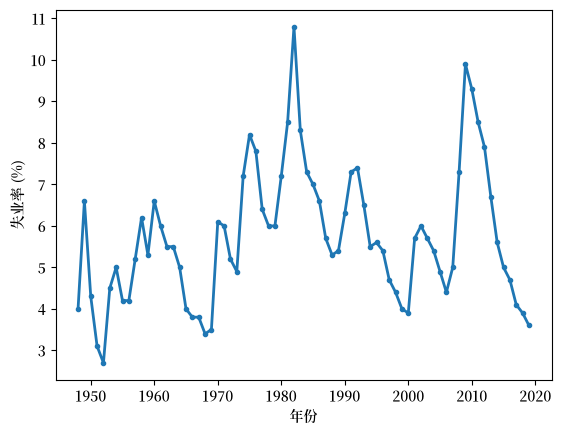

In [4]:
fig, ax = plt.subplots()
ax.plot(years, u_annual, lw=2, marker='o', ms=3)
ax.set_xlabel('年份')
ax.set_ylabel('失业率 (%)')
plt.show()

在 {numref}`fig-annual-data` 中，每次衰退都表现为急剧上升，随后是漫长、缓慢的下降——上升快，下降慢。

## 具有非对称冲击的模型

我们保留 {doc}`unemployment_linear` 中的线性结构：

$$
u_{t+1} = \bar u + \rho\,(u_t - \bar u) + \eta_{t+1},
\qquad 0 \le \rho < 1,
$$ (eq:shocks)

然而在这里，扰动 $\eta_{t+1}$ 是从*两个正态分布的混合*中抽取的：

$$
\eta_{t+1} \sim
\begin{cases}
N(0, \sigma_s^2) & \text{以概率 } 1-p \quad\text{（平静年份）},\\[4pt]
N(\mu_J, \sigma_J^2) & \text{以概率 } p \quad\text{（衰退跳跃）},
\end{cases}
\qquad \mu_J > 0 .
$$

该模型有六个参数：

| 符号 | 名称 | 作用 |
| --- | --- | --- |
| $\bar u$ | 底线 | 序列回归到的低水平 |
| $\rho$ | 持续性 | 回归速度（如线性讲座中所述） |
| $p$ | 跳跃概率 | 大冲击到来的频率 |
| $\mu_J$ | 跳跃幅度 | 衰退平均向上的推动 |
| $\sigma_s,\ \sigma_J$ | 冲击幅度 | 平静与跳跃时的波动率 |

这一机制导致失业率呈现锯齿状动态。

大多数年份是平静的，只有小的噪声。

偶尔一个正向跳跃将失业率大幅推高。

然后，在大多数情况下，线性回归会将其缓慢拉回到 $\bar u$。

因此，激增在一步内到来，而恢复需要时间——这正是我们在数据中观察到的非对称动态。

从精神上讲，这就是米尔顿·弗里德曼的"拨弦模型"：一条接近充分就业的底线，坏冲击从这条底线向上拨动序列。

下一个单元格展示了冲击的密度及其两个组成部分。

findfont: Failed to find font weight normal, now using 600.


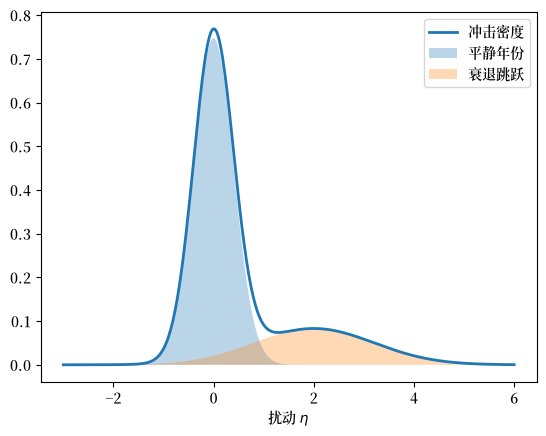

In [5]:
def normal_pdf(x, m, s):
    return np.exp(-(x - m)**2 / (2 * s**2)) / (s * np.sqrt(2 * np.pi))

η = np.linspace(-3, 6, 400)
p_, μJ_, σs_, σJ_ = 0.25, 2.0, 0.4, 1.2
quiet = (1 - p_) * normal_pdf(η, 0.0, σs_)
jump  = p_ * normal_pdf(η, μJ_, σJ_)

fig, ax = plt.subplots()
ax.plot(η, quiet + jump, lw=2, label='冲击密度')
ax.fill_between(η, quiet, alpha=0.3, label='平静年份')
ax.fill_between(η, jump, alpha=0.3, label='衰退跳跃')
ax.set_xlabel('扰动 $\\eta$')
ax.legend()
plt.show()

{numref}`fig-shock-density` 展示了一个在零点处又高又窄的峰值，对应普通年份，加上一个位于正侧的低而宽的隆起，对应衰退跳跃。



## 贝叶斯估计

我们对六个参数施加弱信息先验。

该混合分布使用 NumPyro 的 `MixtureSameFamily` 编写，它会解析地对两个组成部分求和。

In [6]:
def jump_model(u):
    # 设置先验
    ubar = numpyro.sample("ubar",    dist.Normal(4.5, 1.5))  
    ρ    = numpyro.sample("rho",     dist.Uniform(0.0, 1.0))  
    p    = numpyro.sample("p",       dist.Beta(2.0, 8.0))      
    μ_J  = numpyro.sample("mu_J",    dist.HalfNormal(2.0))
    σ_s  = numpyro.sample("sigma_s", dist.HalfNormal(0.5))
    σ_J  = numpyro.sample("sigma_J", dist.HalfNormal(1.5))
    # 构建模型
    n = u.shape[0] - 1
    base   = ubar + ρ * (u[:-1] - ubar)
    locs   = jnp.stack([base, base + μ_J], axis=-1)
    scales = jnp.stack([jnp.broadcast_to(σ_s, (n,)),
                        jnp.broadcast_to(σ_J, (n,))], axis=-1)
    probs  = jnp.broadcast_to(jnp.stack([1 - p, p]), (n, 2))
    mix = dist.MixtureSameFamily(dist.Categorical(probs=probs),
                                 dist.Normal(locs, scales))
    numpyro.sample("u_obs", mix, obs=u[1:])

我们使用 NUTS 进行采样，四条链，向量化处理，因此代码可在 CPU 或 GPU 上运行。

In [7]:
def run_nuts(model, data, seed=0, num_warmup=2000, num_samples=4000, num_chains=4):
    "使用 NUTS 采样器对 NumPyro 模型进行采样。"
    mcmc = MCMC(NUTS(model),
                num_warmup=num_warmup, num_samples=num_samples,
                num_chains=num_chains, chain_method="vectorized",
                progress_bar=False)
    mcmc.run(random.PRNGKey(seed), jnp.asarray(data))
    return mcmc

我们将模型拟合到年度数据。

In [8]:
mcmc_jump = run_nuts(jump_model, u_annual)

让我们看看后验分布。

In [9]:
mcmc_jump.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      mu_J      1.25      0.42      1.20      0.57      1.96   4198.18      1.00
         p      0.35      0.09      0.35      0.20      0.50   4966.77      1.00
       rho      0.83      0.04      0.84      0.76      0.90   5809.25      1.00
   sigma_J      1.29      0.26      1.29      0.89      1.76   4648.01      1.00
   sigma_s      0.39      0.09      0.38      0.25      0.54   4297.53      1.00
      ubar      3.02      0.75      3.08      1.84      4.22   5452.41      1.00

Number of divergences: 0


`r_hat` 值基本上都是 1，因此各条链已经收敛。

注意其中明显的跳跃成分：正常年份的幅度 $\sigma_s$ 很小，而跳跃幅度 $\sigma_J$ 很大，且均值 $\mu_J$ 为正。

让我们做一个快速检查，将拟合的冲击密度叠加到模型的实际残差上，就像我们在 {doc}`unemployment_linear` 中所做的那样。

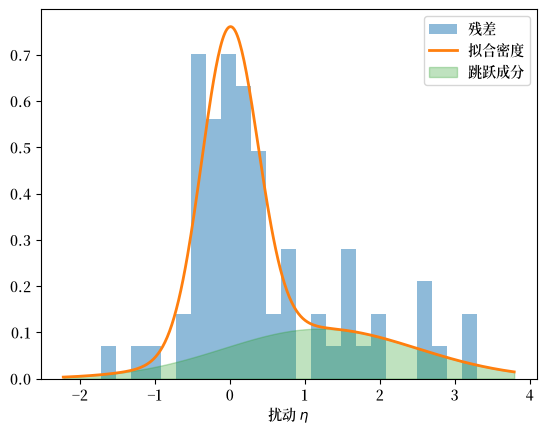

In [10]:
m = {k: np.median(np.asarray(mcmc_jump.get_samples()[k]))
     for k in ("ubar", "rho", "p", "mu_J", "sigma_s", "sigma_J")}
resid = u_annual[1:] - (m["ubar"] + m["rho"] * (u_annual[:-1] - m["ubar"]))

η = np.linspace(resid.min() - 0.5, resid.max() + 0.5, 400)
quiet = (1 - m["p"]) * normal_pdf(η, 0.0, m["sigma_s"])
jump  = m["p"] * normal_pdf(η, m["mu_J"], m["sigma_J"])

fig, ax = plt.subplots()
ax.hist(resid, bins=25, density=True, alpha=0.5, label='残差')
ax.plot(η, quiet + jump, lw=2, label='拟合密度')
ax.fill_between(η, jump, alpha=0.3, color='C2', label='跳跃成分')
ax.set_xlabel('扰动 $\\eta$')
ax.legend()
plt.show()

拟合看起来相当不错（尽管我们仍难以捕捉右尾中的某些大冲击）。


## 用交叉验证比较模型

跳跃模型看起来合理，但它真的比线性模型更好吗？

为了回答这个问题，我们将使用一种*贝叶斯模型比较*的方法。

我们分阶段构建它：指导原则、留一估计，以及计算的实际执行方式。


### 指导原则：样本外预测

我们很容易通过询问哪个模型更好地拟合观测数据来比较两个模型。

但这并不是正确的标准：更复杂的模型总是可以调整得更好地匹配它们所拟合的数据。

正确的问题反而是：哪个模型更好地预测它未曾见过的数据？

换句话说，我们关心的标准是样本外预测精度。

我们没有用于样本外测试的新数据，因此使用*交叉验证*来制造一些。


### 留一交叉验证

其思想是留出一个观测值，将模型拟合到其余数据，然后使用由数据集其余部分构建的预测分布对留出的点进行评分。

给定其余数据 $u_{-i}$，数据点 $u_i$ 的预测分布为

$$
p(u_i \mid u_{-i}) = \int p(u_i \mid \theta)\, p(\theta \mid u_{-i})\, d\theta .
$$

这里 $p(\theta \mid u_{-i})$ 是从 $u_{-i}$ 中的数据获得的后验。

我们用这个密度的*对数*对每个留出的点进行评分。

这会奖励那些对实际发生的事件赋予高概率的模型。

将所有数据点的这些分数相加，就得到了**期望对数预测密度**（elpd），这里是其留一（LOO）形式：

$$
\text{elpd}_{\text{loo}} = \sum_{i=1}^{n} \log p(u_i \mid u_{-i}).
$$


### 计算方法

elpd 的定义表明，我们需要重新拟合模型 $n$ 次，每次对应一个被省略的点。

这将非常耗时。

这里我们讨论一种方法，只保留第一次拟合，使用我们已经采样过的完整后验。


关于记号：设 $u = (u_1, \dots, u_n)$，用 $u_{-i}$ 表示删除了 $u_i$ 后的样本。

该方法依赖于以下独立性类型的假设：


```{prf:assumption}
:label: assm-cond-ind

给定 $\theta$，观测值是条件独立的：

$$
p(u \mid \theta) = \prod_{j=1}^{n} p(u_j \mid \theta) .
$$
```

对于我们的自回归数据，这个假设是错误的，因为每个 $u_i$ 都通过转移动态依赖于早先的观测值。

尽管如此，我们仍然采用它，因为

* 它使得留一计算变得可处理，并且
* 它是一个非常标准的、需要理解的过程。

我们将在下面关于时间序列结构的部分讨论其后果。

在我们的假设条件下，下面的命题是精确的。

```{prf:proposition}
:label: prop-loo-identity

在 {prf:ref}`assm-cond-ind` 下，我们有

$$
\frac{1}{p(u_i \mid u_{-i})}
\;=\;
\int \frac{1}{p(u_i \mid \theta)}\, p(\theta \mid u)\, d\theta
\qquad (i = 1, \dots, n).
$$

```

```{prf:proof}
根据贝叶斯法则，$p(\theta \mid u) = p(u \mid \theta)\, p(\theta) / p(u)$ 且 $p(\theta \mid u_{-i}) = p(u_{-i} \mid \theta)\, p(\theta) / p(u_{-i})$。

根据 {prf:ref}`assm-cond-ind`，$p(u \mid \theta) = p(u_i \mid \theta)\, p(u_{-i} \mid \theta)$。

将两个后验相除并代入这个因式分解，

$$
\frac{p(\theta \mid u)}{p(\theta \mid u_{-i})}
\;=\;
\frac{p(u \mid \theta)}{p(u_{-i} \mid \theta)} \cdot \frac{p(u_{-i})}{p(u)}
\;=\;
p(u_i \mid \theta) \cdot \frac{p(u_{-i})}{p(u)} ,
$$

因此，重新整理后，

$$
\frac{p(\theta \mid u)}{p(u_i \mid \theta)}
\;=\;
\frac{p(u_{-i})}{p(u)}\, p(\theta \mid u_{-i}) .
$$

现在对两边关于 $\theta$ 积分。

在右边，$\int p(\theta \mid u_{-i})\, d\theta = 1$，只剩下常数因子 $p(u_{-i}) / p(u)$，因此

$$
\int \frac{1}{p(u_i \mid \theta)}\, p(\theta \mid u)\, d\theta
\;=\;
\frac{p(u_{-i})}{p(u)}
\;=\;
\frac{1}{p(u_i \mid u_{-i})} ,
$$

最后一个等式源于 $p(u) = p(u_i \mid u_{-i})\, p(u_{-i})$。
```

留-$i$-出的后验已经消失；只剩下完整后验，而我们对它有 $S$ 个抽样 $\theta^1, \dots, \theta^S$。

用这些抽样上的平均值替换 {prf:ref}`prop-loo-identity` 中的积分，得到

$$
\frac{1}{p(u_i \mid u_{-i})}
\;\approx\;
\frac{1}{S} \sum_{s=1}^{S} \frac{1}{p(u_i \mid \theta^s)},
\qquad\text{因此}\qquad
p(u_i \mid u_{-i})
\;\approx\;
\frac{S}{\sum_{s=1}^{S} 1 / p(u_i \mid \theta^s)} ,
$$

这是 $u_i$ 的每个抽样似然的调和平均数。

被积函数具有有限的均值，等于 $1/p(u_i \mid u_{-i})$ 本身，因此大数定律适用。

当 $S \to \infty$ 时，该平均值因此收敛到那个均值，并且在极限处，近似以概率一成为精确的。

其唯一的成分是每个观测值在每个抽样下的似然——**逐点对数似然**——这就是我们一直小心保留它的原因。

为了数值稳定性，我们在对数尺度上计算，此时调和平均数变为

$$
\log p(u_i \mid u_{-i})
\;\approx\;
\log S - \log \sum_{s=1}^{S} e^{-\ell_i^s},
\qquad \ell_i^s = \log p(u_i \mid \theta^s),
$$

这就是我们下面使用的 `jnp.log(S) - logsumexp(-ll)`。

为了与线性模型进行比较，我们首先在相同的数据上拟合它。

In [11]:
def linear_model(u):
    ubar = numpyro.sample("ubar",  dist.Normal(5.5, 2.0))
    ρ    = numpyro.sample("rho",   dist.Uniform(0.0, 1.0))
    σ    = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("u_obs", dist.Normal(ubar + ρ * (u[:-1] - ubar), σ), obs=u[1:])

我们在相同的年度数据上对其采样。

In [12]:
mcmc_lin = run_nuts(linear_model, u_annual)

现在我们可以用几行代码手动完成整个留一计算。

In [13]:
from jax.scipy.special import logsumexp

def pointwise_loo(mcmc, model):
    "每个观测值的留一对数预测密度。"
    ll = log_likelihood(model, mcmc.get_samples(),
                        u=jnp.asarray(u_annual))["u_obs"]  # (抽样, 观测)
    S = ll.shape[0]
    # 每个观测值的每抽样似然的调和平均数的对数
    return jnp.log(S) - logsumexp(-ll, axis=0)

elpd_jump = pointwise_loo(mcmc_jump, jump_model)
elpd_lin  = pointwise_loo(mcmc_lin,  linear_model)

print(f"jump   elpd_loo = {elpd_jump.sum():.1f}")
print(f"linear elpd_loo = {elpd_lin.sum():.1f}")

jump   elpd_loo = -93.9
linear elpd_loo = -105.8


跳跃模型得分更高（更接近零），因此在样本外预测上它获胜。

为了帮助理解这个差距是否真实，我们计算其标准误差：

In [14]:
diff = elpd_jump - elpd_lin
n = diff.size
print(f"elpd difference = {diff.sum():.1f}")
print(f"standard error  = {jnp.sqrt(n) * diff.std():.1f}")

elpd difference = 11.9
standard error  = 5.7


跳跃模型领先约十二个点，而标准误差接近六——略超过两个标准误差，因此是一个真实的改进。

### ArviZ 实现

在实践中，大多数人使用像 ArviZ 这样的库来进行这个计算。

我们将相同的逐点对数似然以其数据格式打包交给它。

In [15]:
import arviz as az
import xarray as xr

def to_arviz(mcmc, model, u):
    "为 ArviZ 打包 NumPyro 拟合结果，附带逐点对数似然。"
    idata = az.from_numpyro(mcmc)
    ll = np.asarray(log_likelihood(model, mcmc.get_samples(),
                                   u=jnp.asarray(u))["u_obs"])
    ll = ll.reshape(mcmc.num_chains, -1, ll.shape[-1])
    idata["log_likelihood"] = xr.Dataset(
        {"u_obs": (("chain", "draw", "obs"), ll)})
    return idata

az.compare({
    "linear": to_arviz(mcmc_lin,  linear_model, u_annual),
    "jump":   to_arviz(mcmc_jump, jump_model,   u_annual),
})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
jump,0,0.0,0.0,NaN,,,6.5,-90.0,9.2,0.86
linear,1,-10.0,5.7,0.98,N < 100,,3.6,-110.0,7.3,0.14


这里 `az.compare` 确认了手工计算，并将跳跃模型排在第一位（其表格为了显示对分数进行了取整）。



### 适应时间序列结构

留一法每次删除一个转移，但它并不尊重时间的顺序。

当它对从 $u_t$ 到 $u_{t+1}$ 的步骤进行评分时，进行评分的模型是在位于该步骤*两侧*的数据上拟合的——包括相邻值 $u_t$ 和 $u_{t+1}$ 本身。

因此，留出的点从未真正未被看见。

形式上正确的度量是**留未来交叉验证**。

它只向前预测：在 $u_1, \dots, u_t$ 上拟合模型，对其提前一步预测 $u_{t+1}$ 进行评分，然后将窗口扩展一步并重复。

现在模型对它被要求预测的未来是真正盲目的，这正如真实的预测。

代价是计算量。

留一法通过其重要性采样的捷径重用了单次拟合，但留未来法没有这样的技巧。

对于我们这条短的年度序列，留未来交叉验证仍然可行，但对于长序列，它可能变得难以承受。

（我们在此处未纳入的情况下运行了它，结论依然成立：在留未来法下，跳跃模型仍然击败线性模型，且优势幅度更大。）



## 结论


在 {doc}`unemployment_linear` 中，我们对失业率应用了带高斯冲击的线性 AR(1) 模型，并在月度数据中发现了高水平的持续性。

我们还论证了该模型过于简单。

在这里，我们发现线性模型最明显遗漏的特征——衰退的非对称性——可以通过对冲击的分布进行建模来解决。

带有大的、单侧扰动的线性回归匹配了高斯模型无法捕捉的右偏、重尾冲击。

交叉验证更偏好它。

一个比上面所考虑的更好的模型将允许经济在持续扩张和衰退状态之间切换。

这就是马尔可夫切换方法，我们将其留作进一步阅读。

## 练习

```{exercise}
:label: unemp_shocks_ex1

这里的跳跃成分本身是对称的，$N(\mu_J, \sigma_J^2)$。

将两成分混合替换为单一的**偏正态**（或带偏度的 Student-$t$）扰动，重新拟合，并使用 `az.compare` 与混合模型进行比较。

更简单的偏斜冲击表现得和混合模型一样好吗？
```